In [30]:
import requests
import os
from pathlib import Path

data_dir = Path("data/raw")
data_dir.mkdir(parents=True, exist_ok=True)

taxi_file = data_dir / "taxi_data.parquet"
zone_file = data_dir / "taxi_zone_lookup.csv"

# Only download taxi data if not already present
if not taxi_file.exists():
    url1 = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
    response1 = requests.get(url1)
    response1.raise_for_status()
    taxi_file.write_bytes(response1.content)
    print("Taxi data downloaded.")
else:
    print("Taxi data already exists. Skipping download.")

# Only download zone lookup if not already present
if not zone_file.exists():
    url2 = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
    response2 = requests.get(url2)
    response2.raise_for_status()
    zone_file.write_bytes(response2.content)
    print("Zone lookup downloaded.")
else:
    print("Zone lookup already exists. Skipping download.")

print("Download check complete!")

Taxi data already exists. Skipping download.
Zone lookup already exists. Skipping download.
Download check complete!


In [31]:

import polars as pl
import sys
from polars import Datetime

try:
        df = pl.read_parquet("data/raw/taxi_data.parquet")
        required_cols = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID","DOLocationID",
                        "passenger_count", "trip_distance", "fare_amount", "tip_amount", "total_amount", "payment_type"]
        
        missing = [col for col in required_cols if col not in df.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")
            
        date_cols = ("tpep_pickup_datetime", "tpep_dropoff_datetime")
        for col in date_cols:
            if df.schema[col] != pl.Datetime:
                raise TypeError(f"{col} is not of type Datetime")

        print(f"Number of rows in the dataframe: {len(df):,}")

except Exception as e:
    print(f"Error loading data: {e}")

Number of rows in the dataframe: 2,964,624


In [32]:
import polars as pl

def apply_filter(df, condition, message):
    start_rows = df.height
    df = df.filter(condition)
    removed = start_rows - df.height
    print(f"{message}: {removed:,}")
    return df

# Initial row count
print(f"Starting rows: {df.height:,}")

# Drop nulls
start_rows = df.height
df = df.drop_nulls(subset=[
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "fare_amount"
])
print(f"Rows removed with nulls: {start_rows - df.height:,}")

# Sequential filters
df = apply_filter(df, pl.col('passenger_count') > 0,
                  "Rows removed where passenger_count <= 0")

df = apply_filter(df, pl.col('trip_distance') > 0,
                  "Rows removed where trip_distance <= 0")

df = apply_filter(df, pl.col('fare_amount') > 0,
                  "Rows removed where fare_amount <= 0")

df = apply_filter(df, pl.col('fare_amount') < 500,
                  "Rows removed where fare_amount >= 500")

df = apply_filter(df, pl.col('tip_amount') >= 0,
                  "Rows removed where tip_amount < 0")

df = apply_filter(df, pl.col('total_amount') > 0,
                  "Rows removed where total_amount <= 0")

df = apply_filter(
    df,
    pl.col("tpep_dropoff_datetime") >= pl.col("tpep_pickup_datetime"),
    "Rows removed where dropoff before pickup"
)

# --- Payment Type Cleaning ---

# Count how many will be changed
invalid_payment_rows = df.filter(
    (pl.col("payment_type") < 0) | (pl.col("payment_type") > 6)
).height

df = df.with_columns(
    pl.when((pl.col("payment_type") < 0) | (pl.col("payment_type") > 6))
      .then(5)
      .otherwise(pl.col("payment_type"))
      .alias("payment_type")
)

df = apply_filter(df, pl.col('payment_type') == 1,"Using only rows with Credit Card Payments")

print(f"Payment type values corrected: {invalid_payment_rows:,}")
print(f"Final number of rows in the dataframe: {df.height:,}")

Starting rows: 2,964,624
Rows removed with nulls: 0
Rows removed where passenger_count <= 0: 171,627
Rows removed where trip_distance <= 0: 36,763
Rows removed where fare_amount <= 0: 32,429
Rows removed where fare_amount >= 500: 34
Rows removed where tip_amount < 0: 0
Rows removed where total_amount <= 0: 0
Rows removed where dropoff before pickup: 8
Using only rows with Credit Card Payments: 450,193
Payment type values corrected: 0
Final number of rows in the dataframe: 2,273,570


In [33]:
invalid_payment = df.filter((pl.col('payment_type') < 0) | (pl.col('payment_type') > 5)).sample(n=10, with_replacement=True)
print(f"Number of invalid payment records: {len(invalid_payment)}")

invalid_pc = df.filter(pl.col('passenger_count') <= 0).sample(n=10, with_replacement=True)
print(f"Records with passenger_count <= 0: {len(invalid_pc)}")

invalid_td = df.filter(pl.col('trip_distance') <= 0).sample(n=10, with_replacement=True)
print(f"Records with trip_distance <= 0: {len(invalid_td)}")

invalid_fa = df.filter(pl.col('fare_amount') <= 0).sample(n=10, with_replacement=True)
print(f"Records with fare_amount <= 0: {len(invalid_fa)}")

invalid_ta = df.filter(pl.col('tip_amount') < 0).sample(n=10, with_replacement=True)
print(f"Records with tip_amount < 0: {len(invalid_ta)}")

invalid_total = df.filter(pl.col('total_amount') <= 0).sample(n=10, with_replacement=True)
print(f"Records with total_amount <= 0: {len(invalid_total)}")


Number of invalid payment records: 0
Records with passenger_count <= 0: 0
Records with trip_distance <= 0: 0
Records with fare_amount <= 0: 0
Records with tip_amount < 0: 0
Records with total_amount <= 0: 0


## Part 1: Data Preprocessing & Feature Engineering

In [34]:
#Temporal Features
## pickup_hour, pickup_day_of_week (numeric, 0=Monday), is_weekend (boolean)
weekday_map = {
    0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday",
    4: "Friday", 5: "Saturday", 6: "Sunday"
}
df = df.with_columns([
    pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour'),

    pl.col('tpep_pickup_datetime')
        .dt.weekday()
        .map_elements(lambda x: weekday_map.get(x, "Unknown"), return_dtype=pl.Utf8)
        .alias('pickup_day_of_week'),

    pl.col('tpep_pickup_datetime') 
        .dt.weekday()
        .is_in([5,6])
        .alias("is_weekend")   
])
#Trip features
##: trip_duration_minutes, trip_speed_mph, log_trip_distance (log transformed distance) 

duration_hours = (
    (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
    .dt.total_seconds() / 3600
)

duration_minutes = duration_hours * 60

df = df.with_columns([
    ((pl.col('tpep_dropoff_datetime') - pl.col('tpep_pickup_datetime'))
        .dt.total_seconds() / 60).alias('trip_duration_minutes'),

    (pl.when(duration_hours > 0)
        .then(pl.col("trip_distance") / duration_hours)
        .otherwise(0)
        .clip(0, 80)
    ).alias("trip_speed_mph"),


    pl.col('trip_distance')
        .log()
        .alias('log_trip_distance')

])


#Fare features
##  fare_per_mile (fare_amount / trip_distance, handle division by zero), fare_per_minute (fare_amount / trip_duration_minutes) 
df = df.with_columns([
    (pl.col('fare_amount') / pl.col('trip_distance')) #already removed all 0 and negative trip distances 
        .alias('fare_per_mile'),

    (pl.when(pl.col('trip_duration_minutes') > 0)
        .then(pl.col('fare_amount') / pl.col('trip_duration_minutes'))
        .otherwise('fare_amount')
        ).alias('fare_per_minute')
])

#Zone features
## Encode pickup and dropoff borough using the taxi zone lookup table (use one-hot encoding or label encoding) 
zone_lookup = pl.read_csv("data/raw/taxi_zone_lookup.csv")
pickup_lookup = zone_lookup.select([
    pl.col('LocationID'),
    pl.col('Borough').alias('pickup_borough')
])

dropoff_lookup = zone_lookup.select([
    pl.col('LocationID'),
    pl.col('Borough').alias('dropoff_borough')
])

df = df.join(
    pickup_lookup,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

df = df.join(
    dropoff_lookup,
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
)

df = df.with_columns([
    pl.col('pickup_borough').cast(pl.Categorical).to_physical().alias('pickup_borough_label'),
    pl.col('dropoff_borough').cast(pl.Categorical).to_physical().alias('dropoff_borough_label')
])

In [35]:
df.select(['pickup_hour','pickup_day_of_week',  'is_weekend', 'trip_duration_minutes','trip_speed_mph','log_trip_distance','fare_per_mile','fare_per_minute','PULocationID','pickup_borough','pickup_borough_label','DOLocationID','dropoff_borough','dropoff_borough_label']).head()


pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute,PULocationID,pickup_borough,pickup_borough_label,DOLocationID,dropoff_borough,dropoff_borough_label
i8,str,bool,f64,f64,f64,f64,f64,i32,str,u32,i32,str,u32
0,"""Tuesday""",false,6.6,16.363636,0.587787,5.555556,1.515152,140,"""Manhattan""",0,236,"""Manhattan""",0
0,"""Tuesday""",false,17.916667,15.739535,1.547563,4.957447,1.300465,236,"""Manhattan""",0,79,"""Manhattan""",0
0,"""Tuesday""",false,8.3,10.120482,0.336472,7.142857,1.204819,79,"""Manhattan""",0,211,"""Manhattan""",0
0,"""Tuesday""",false,6.1,7.868852,-0.223144,9.875,1.295082,211,"""Manhattan""",0,148,"""Manhattan""",0
0,"""Tuesday""",false,32.383333,8.708183,1.547563,6.297872,0.91405,148,"""Manhattan""",0,141,"""Manhattan""",0


In [36]:
df.schema

Schema([('VendorID', Int32),
        ('tpep_pickup_datetime', Datetime(time_unit='ns', time_zone=None)),
        ('tpep_dropoff_datetime', Datetime(time_unit='ns', time_zone=None)),
        ('passenger_count', Int64),
        ('trip_distance', Float64),
        ('RatecodeID', Int64),
        ('store_and_fwd_flag', String),
        ('PULocationID', Int32),
        ('DOLocationID', Int32),
        ('payment_type', Int64),
        ('fare_amount', Float64),
        ('extra', Float64),
        ('mta_tax', Float64),
        ('tip_amount', Float64),
        ('tolls_amount', Float64),
        ('improvement_surcharge', Float64),
        ('total_amount', Float64),
        ('congestion_surcharge', Float64),
        ('Airport_fee', Float64),
        ('pickup_hour', Int8),
        ('pickup_day_of_week', String),
        ('is_weekend', Boolean),
        ('trip_duration_minutes', Float64),
        ('trip_speed_mph', Float64),
        ('log_trip_distance', Float64),
        ('fare_per_mile', Float64),

## Target Variable Generation, reusing existing tip_amount in the future

In [37]:
df = df.with_columns([

    ((pl.col("tip_amount") > pl.col("fare_amount") * 0.20)
        .cast(pl.Int8)
    ).alias("high_tip")
])

Setting up the Splits for training

In [38]:
from sklearn.model_selection import train_test_split

df_pd = df.to_pandas()

train_df, temp_df = train_test_split(
    df_pd,
    test_size=0.30,
    stratify=df_pd["high_tip"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["high_tip"],
    random_state=42
)

Number of samples in the splits as well as the class distribution for `high_tip`

In [39]:
print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Train samples: 1591499
Validation samples: 341035
Test samples: 341036


In [40]:
print("Train class distribution:")
print(train_df["high_tip"].value_counts())
print(train_df["high_tip"].value_counts(normalize=True))

Train class distribution:
high_tip
1    1208620
0     382879
Name: count, dtype: int64
high_tip
1    0.759422
0    0.240578
Name: proportion, dtype: float64


In [41]:
print("Validation class distribution:")
print(val_df["high_tip"].value_counts())
print(val_df["high_tip"].value_counts(normalize=True))

Validation class distribution:
high_tip
1    258990
0     82045
Name: count, dtype: int64
high_tip
1    0.759424
0    0.240576
Name: proportion, dtype: float64


In [42]:
print("Test class distribution:")
print(test_df["high_tip"].value_counts())
print(test_df["high_tip"].value_counts(normalize=True))

Test class distribution:
high_tip
1    258990
0     82046
Name: count, dtype: int64
high_tip
1    0.759421
0    0.240579
Name: proportion, dtype: float64


In [43]:
X_train = train_df.drop(columns=["tip_amount", "high_tip"])


y_train_reg = train_df["tip_amount"]


y_train_clf = train_df["high_tip"]

Some numeric features were used, I left out any ID values, date values, classification type boolean values as well as values that are being targeted by the classification and regression.

In [44]:
numeric_features = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "pickup_hour",
    "trip_duration_minutes",
    "trip_speed_mph",
    "log_trip_distance"
]

print("Model Features:")
for col in numeric_features:
    print(f"{col} - numeric (scaled)")

print("\nExcluded Features:")
excluded = ["tip_amount", "high_tip",
            "VendorID", "PULocationID", "DOLocationID",
            "tpep_pickup_datetime", "tpep_dropoff_datetime",
            "pickup_borough", "dropoff_borough"]

for col in excluded:
    print(col)
#    

Model Features:
passenger_count - numeric (scaled)
trip_distance - numeric (scaled)
fare_amount - numeric (scaled)
extra - numeric (scaled)
mta_tax - numeric (scaled)
tolls_amount - numeric (scaled)
improvement_surcharge - numeric (scaled)
congestion_surcharge - numeric (scaled)
Airport_fee - numeric (scaled)
pickup_hour - numeric (scaled)
trip_duration_minutes - numeric (scaled)
trip_speed_mph - numeric (scaled)
log_trip_distance - numeric (scaled)

Excluded Features:
tip_amount
high_tip
VendorID
PULocationID
DOLocationID
tpep_pickup_datetime
tpep_dropoff_datetime
pickup_borough
dropoff_borough


In [45]:
from sklearn.preprocessing import StandardScaler



scaler = StandardScaler()

scaler.fit(train_df[numeric_features])

train_df[numeric_features] = scaler.transform(train_df[numeric_features])
val_df[numeric_features] = scaler.transform(val_df[numeric_features])
test_df[numeric_features] = scaler.transform(test_df[numeric_features])


train_df[numeric_features].describe()

,passenger_count,trip_distance,fare_amount,extra,mta_tax,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee,pickup_hour,trip_duration_minutes,trip_speed_mph,log_trip_distance
count,1.591499e+06,1.591499e+06,1.591499e+06,1.591499e+06,1.591499e+06,1.591499e+06,1.591499e+06,1.591499e+06,1.591499e+06,1.591499e+06,1.591499e+06,1.591499e+06,1.591499e+06
mean,-1.476537e-16,-6.464760e-18,2.207305e-17,-7.050517e-17,-8.214888e-17,5.514690e-17,1.103409e-14,-3.762062e-16,-1.930499e-17,5.082516e-17,2.228735e-17,-2.571617e-17,7.107664e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-4.109533e-01,-2.102232e-01,-1.083779e+00,-1.690664e+00,-1.240527e+01,-2.636911e-01,-1.187408e+02,-3.945104e+00,-2.929083e-01,-2.530101e+00,-4.681329e-01,-1.717958e+00,-5.602517e+00
25%,-4.109533e-01,-1.451210e-01,-5.773449e-01,-8.610033e-01,7.928461e-02,-2.636911e-01,1.097606e-02,2.534801e-01,-2.929083e-01,-5.870477e-01,-2.511892e-01,-6.058138e-01,-6.842139e-01
50%,-4.109533e-01,-1.023578e-01,-3.297288e-01,-3.078964e-01,7.928461e-02,-2.636911e-01,1.097606e-02,2.534801e-01,-2.929083e-01,1.195169e-01,-1.196330e-01,-2.697936e-01,-1.524867e-01
75%,-4.109533e-01,-1.172525e-02,8.296468e-02,5.217640e-01,7.928461e-02,-2.636911e-01,1.097606e-02,2.534801e-01,-2.929083e-01,8.260816e-01,8.986406e-02,2.322198e-01,4.918697e-01
max,9.209477e+00,9.827256e+02,2.750940e+01,7.020770e+00,8.747116e+01,4.752347e+01,1.097606e-02,2.534801e-01,3.414038e+00,1.532646e+00,4.242168e+01,1.024201e+01,9.516514e+00


In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

feature_cols =[
    "passenger_count",
    "trip_distance",
    "log_trip_distance",
    "trip_duration_minutes",
    "trip_speed_mph",
    "pickup_hour",
    "is_weekend",
    "pickup_borough_label",
    "dropoff_borough_label",
    "fare_amount",
    "extra",
    "mta_tax",
    "tolls_amount",
    "congestion_surcharge",
    "Airport_fee",
    "fare_per_mile",
    "fare_per_minute"
]

# Features
X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

# Regression targets
y_train_reg = train_df["tip_amount"]
y_val_reg = val_df["tip_amount"]
y_test_reg = test_df["tip_amount"]

# Classification targets
y_train_clf = train_df["high_tip"]
y_val_clf = val_df["high_tip"]
y_test_clf = test_df["high_tip"]

#Neural Network targets
X_train_nn = train_df[feature_cols].to_numpy(dtype=np.float32)
X_val_nn = val_df[feature_cols].to_numpy(dtype=np.float32)
X_test_nn = test_df[feature_cols].to_numpy(dtype=np.float32)

y_train_nn = train_df["high_tip"].to_numpy(dtype=np.float32).reshape(-1, 1)
y_val_nn = val_df["high_tip"].to_numpy(dtype=np.float32).reshape(-1, 1)
y_test_nn = test_df["high_tip"].to_numpy(dtype=np.float32).reshape(-1, 1)

train_dataset = TensorDataset(
    torch.tensor(X_train_nn),
    torch.tensor(y_train_nn)
)

val_dataset = TensorDataset(
    torch.tensor(X_val_nn),
    torch.tensor(y_val_nn)
)

test_dataset = TensorDataset(
    torch.tensor(X_test_nn),
    torch.tensor(y_test_nn)
)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

# Start MLflow

## Part 1: Experiment Tracking with MLflow

Task 1.1

In [49]:
import mlflow
import mlflow.sklearn
import mlflow.pytorch

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("taxi-tip-prediction")

2026/04/18 16:20:13 INFO mlflow.tracking.fluent: Experiment with name 'taxi-tip-prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1776543613160, experiment_id='1', last_update_time=1776543613160, lifecycle_stage='active', name='taxi-tip-prediction', tags={}, trace_location=None, workspace='default'>

In [50]:
import joblib

# Load models
rf_model = joblib.load("models/random_forest_reg.pkl")
linear_model = joblib.load("models/linear_reg.pkl")

# Load preprocessing
scaler = joblib.load("models/scaler.pkl")
features = joblib.load("models/features.pkl")

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

with mlflow.start_run(run_name="random_forest_loaded"):

    preds = rf_model.predict(X_test)

    mae = mean_absolute_error(y_test_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    r2 = r2_score(y_test_reg, preds)

    mlflow.log_param("model_type", "RFRegression")
    mlflow.log_param("n_estimators", rf_model.n_estimators)
    mlflow.log_param("max_depth", rf_model.max_depth)
    mlflow.log_param("min_samples_split", rf_model.min_samples_split)
    mlflow.log_param("min_samples_leaf", rf_model.min_samples_leaf)
    mlflow.log_param("random_state", rf_model.random_state)

    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)

    mlflow.sklearn.log_model(rf_model, "model")

    mlflow.set_tag("model_type", "RandomForest")
    mlflow.set_tag("dataset", "NYC Taxi")

2026/04/18 16:38:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 16:38:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run random_forest_loaded at: http://127.0.0.1:5000/#/experiments/1/runs/6a32d9959d6d4beaa9361dc6dbcec2a7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [ ]:
with mlflow.start_run(run_name="linear_regression_loaded"):

    preds = linear_model.predict(X_test)

    mae = mean_absolute_error(y_test_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    r2 = r2_score(y_test_reg, preds)


    mlflow.log_param("model_type", "LinearRegression")

    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)

    mlflow.sklearn.log_model(linear_model, "model")

    mlflow.set_tag("model_type", "LinearRegression")
    mlflow.set_tag("dataset", "NYC Taxi")

2026/04/18 16:20:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 16:20:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run linear_regression_loaded at: http://127.0.0.1:5000/#/experiments/1/runs/0c9437763fa24a768ed7fb0c7d1eb728
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


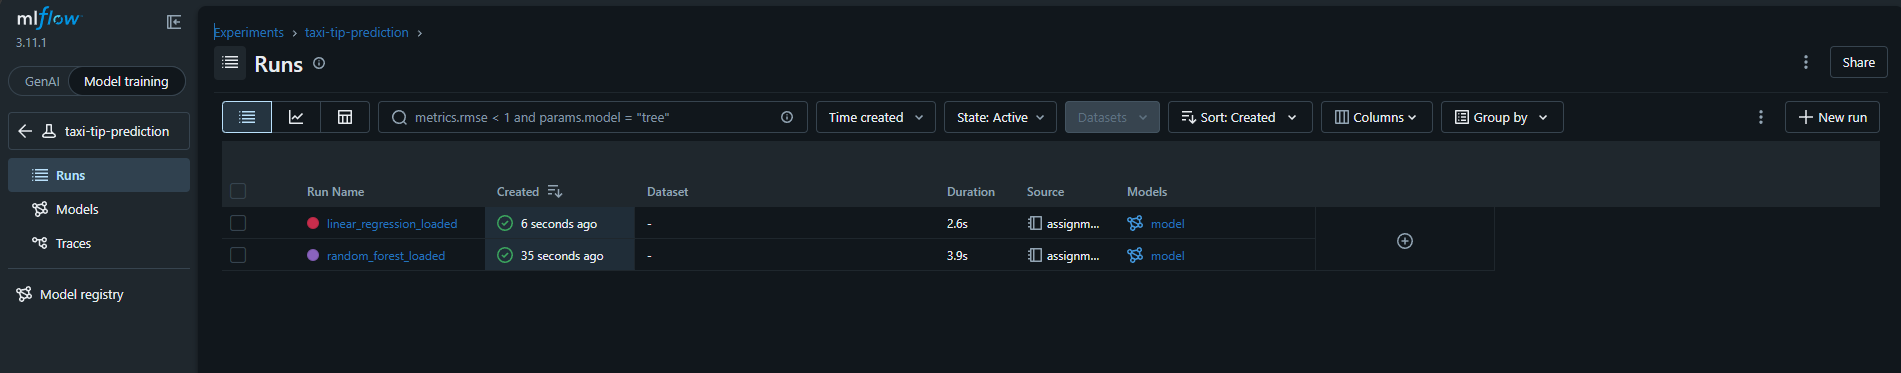

Task 1.2

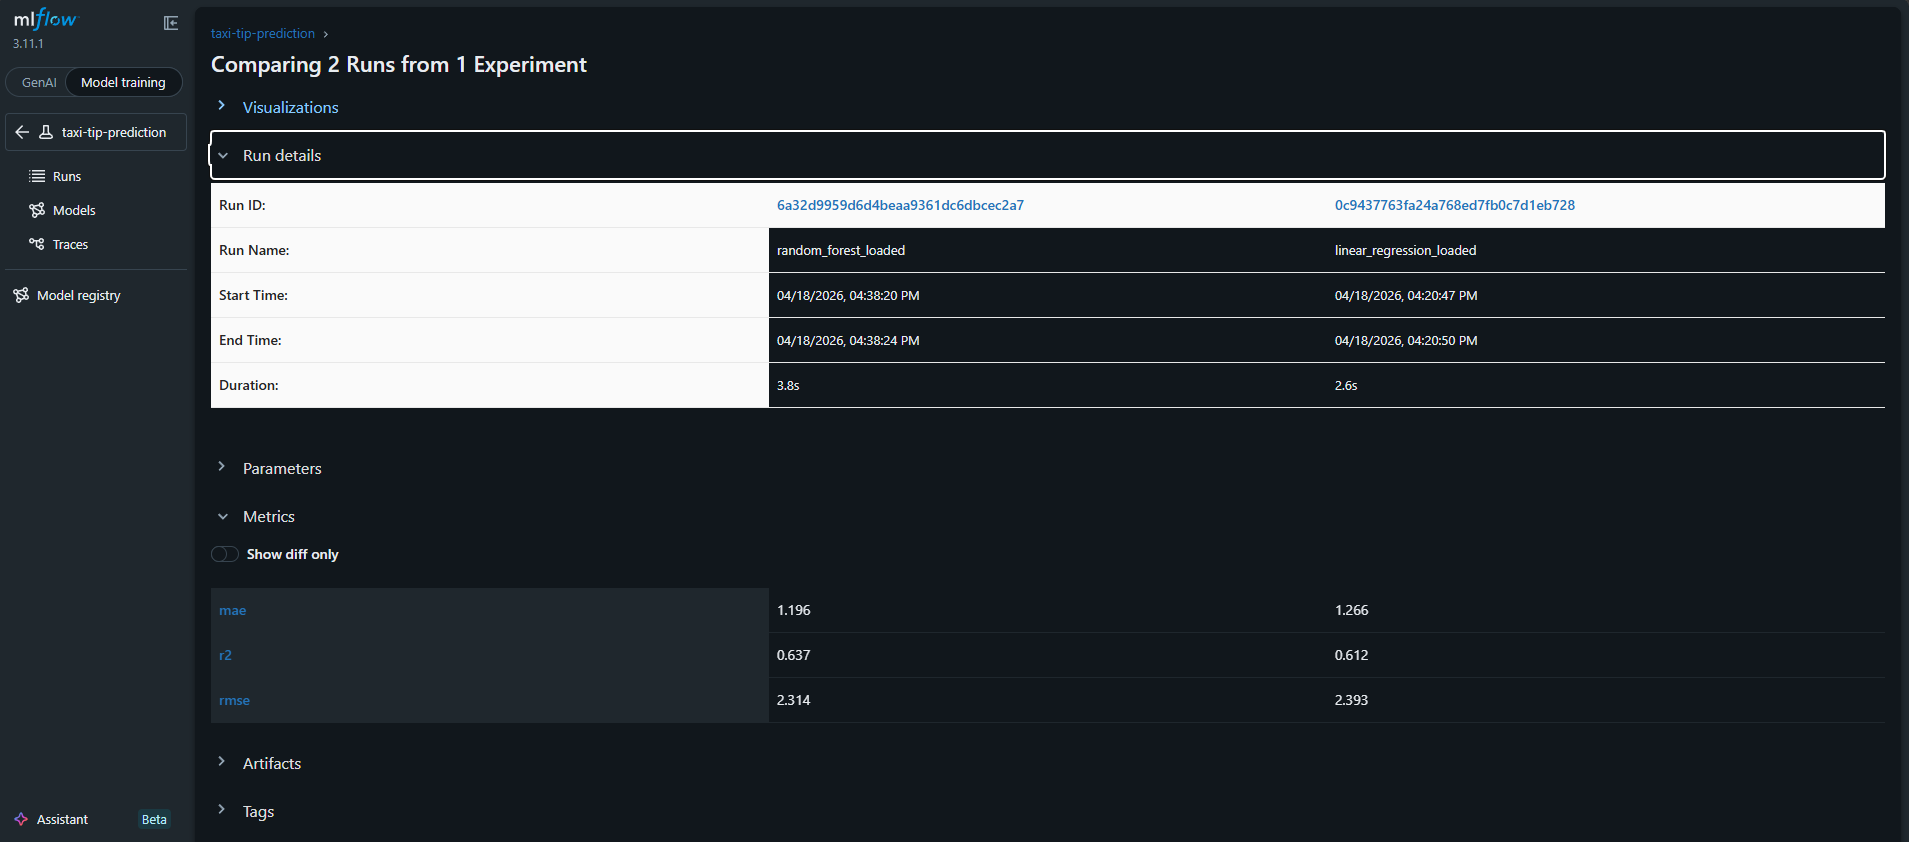

The Random Forest model performed best as its metrics MAE and RSME being error metrics score lower and the r2 score is higher.

In [56]:
model = mlflow.sklearn.load_model("models:/taxi-tip-regressor/1")

sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Prediction:", round(prediction[0], 2))

Prediction: 4.31


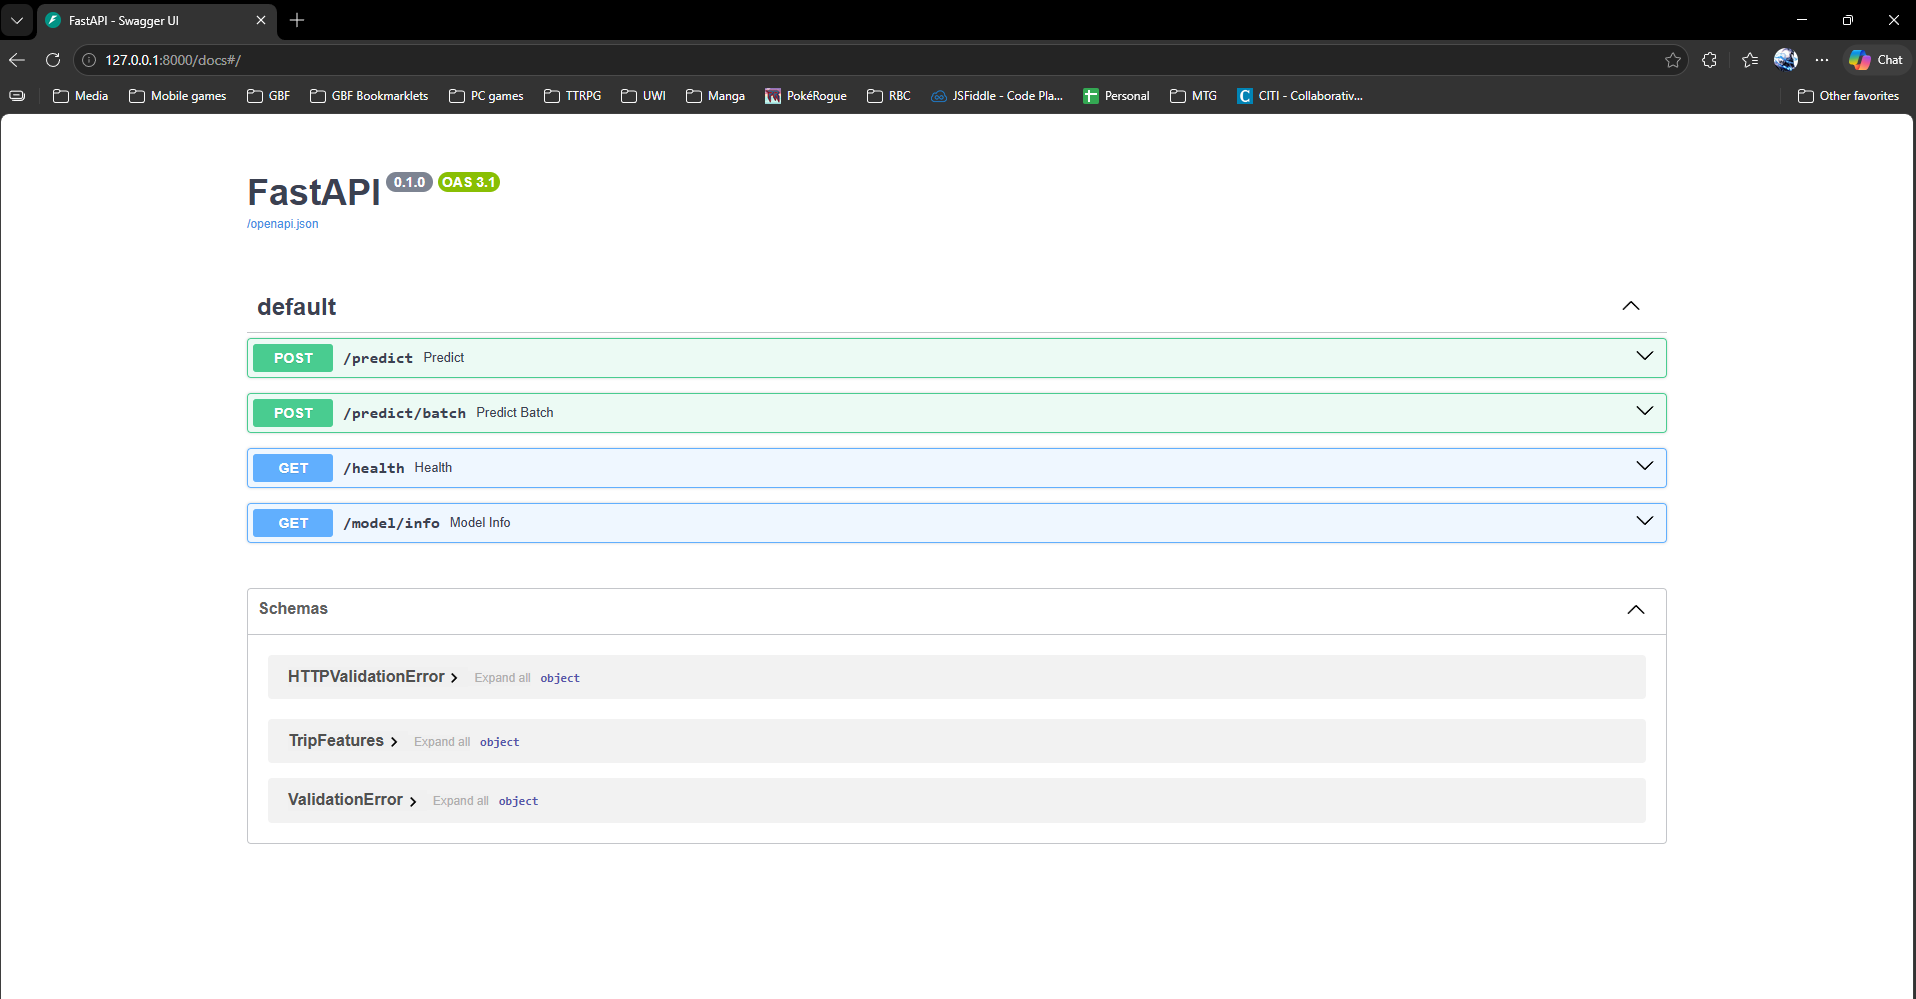

# Part 3: Containerization with Docker